# PL1 — From Tokens to Text
### UMinho · Generative AI · MSc in Artificial Intelligence · Lab 1

In this lab you build the two ends of every language model, the **tokenizer** (text → integers) and the **decoder** (probabilities → text) — and, in between, a small **n-gram language model** evaluated with **perplexity**.

| Part | Topic | Suggested time |
|---|---|---|
| 1 | Byte-Pair Encoding from scratch
| 2 | Production tokenizers and the multilingual token tax
| 3 | N-gram language models and perplexity
| 4 | Decoding strategies
| 5 | Scaling laws, back of the envelope (**homework**)

**Instructions:** Fill every cell marked `# TODO` and every *Your answer* cell. Cells starting with `# CHECK` test your implementation: run them, they must pass silently. Keep answers short (2–5 sentences) and grounded in the numbers you obtained.

**Names / student numbers: CARLOS BERGUEIRA / PG11605

## 0. Setup
Run this once. On Google Colab, upload the `data/` folder (or mount Drive) so that `data/tiny_shakespeare.txt` and `data/parallel_sentences.tsv` are reachable.

In [1]:
# If needed: !pip install -q tiktoken numpy matplotlib
import math, time, random
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt

random.seed(0)
rng = np.random.default_rng(0)

with open("data/tiny_shakespeare.txt", encoding="utf-8") as f:
    corpus = f.read()
print(f"{len(corpus):,} characters")
print(corpus[:250])

1,115,394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



---
## Part 1 — Byte-Pair Encoding from scratch

Modern LLM tokenizers (GPT-2 onwards, Llama, Mistral, …) use **byte-level BPE**. We start from the UTF-8 bytes of the text, so the initial vocabulary is the 256 possible byte values and *no string is ever out-of-vocabulary*. Training repeats one step:

1. count every pair of adjacent token ids;
2. take the most frequent pair `(a, b)`;
3. create a new token id for it and replace every occurrence of `(a, b)` by that id.

After `m` merges the vocabulary has `256 + m` entries. Encoding new text applies the learned merges **in the order they were learned**.

We train on the first 50 000 characters of the corpus to keep things fast (pure Python).

In [2]:
bpe_train_text = corpus[:50_000]
bpe_test_text  = corpus[-20_000:]          # held-out slice from the end of the corpus

### Exercise 1.1 — The two primitives
Implement `get_pair_counts(ids)` (a `Counter` over adjacent pairs) and `merge(ids, pair, new_id)` (left-to-right, non-overlapping replacement).

In [3]:
from collections import Counter

def get_pair_counts(ids):
    return Counter((ids[i], ids[i + 1]) for i in range(len(ids) - 1))


def merge(ids, pair, new_id):
    result = []
    i = 0
    while i < len(ids):
        if i < len(ids) - 1 and (ids[i], ids[i + 1]) == pair:
            result.append(new_id)
            i += 2
        else:
            result.append(ids[i])
            i += 1
    return result


In [4]:
# CHECK 1.1
assert get_pair_counts([1, 2, 3, 1, 2]) == Counter({(1, 2): 2, (2, 3): 1, (3, 1): 1})
assert merge([1, 2, 3, 1, 2], (1, 2), 99) == [99, 3, 99]
assert merge([5, 5, 5], (5, 5), 7) == [7, 5]           # non-overlapping, left to right
print("1.1 OK")

1.1 OK


### Exercise 1.2 — Training, encoding, decoding
In Exercise 1.1, you implemented the two basic operations needed by BPE:

* get_pair_counts(ids) counts how often each adjacent pair of token IDs occurs.
* merge(ids, pair, new_id) replaces all non-overlapping occurrences of a pair with a new token ID.

Now, use these two operations to build a complete, simplified byte-level BPE tokenizer.
The tokenizer has four main steps:

* 1. Training: learn which pairs should be merged.
* 2. Vocabulary construction: determine which bytes each token ID represents.
* 3. Encoding: convert new text into token IDs using the learned merges.
* 4. Decoding: convert token IDs back into text.

Implement:
* `train_bpe(text, vocab_size)` → It should learn the BPE merge rules from text and return an **ordered** dictionary called `merges`, `dict` `{(a, b): new_id}`, with new ids 256, 257, …
* `build_vocab(merges)` → `dict` `{id: bytes}` (ids 0–255 are single bytes; a merged id is the concatenation of its two parts).
* `encode(text, merges)` → list of ids. At each step, among the pairs present, merge the one that was **learned earliest** (lowest new id). Stop when no present pair is in `merges`.
* `decode(ids, vocab)` → string (use `errors="replace"`).

In [5]:
def train_bpe(text, vocab_size, verbose=False):
    assert vocab_size >= 256
    ids = list(text.encode("utf-8"))
    merges = {}

    for new_id in range(256, vocab_size):
        pair_counts = get_pair_counts(ids)
        if not pair_counts:
            break
        pair = max(pair_counts, key=pair_counts.get)
        merges[pair] = new_id
        ids = merge(ids, pair, new_id)
        if verbose:
            print(f"{new_id}: {pair} -> {new_id}")

    return merges


def build_vocab(merges):
    vocab = {i: bytes([i]) for i in range(256)}
    for (a, b), new_id in merges.items():
        vocab[new_id] = vocab[a] + vocab[b]
    return vocab


def encode(text, merges):
    ids = list(text.encode("utf-8"))

    while True:
        mergeable = [
            (merges[pair], pair)
            for pair in zip(ids, ids[1:])
            if pair in merges
        ]
        if not mergeable:
            break

        _, pair = min(mergeable)
        ids = merge(ids, pair, merges[pair])

    return ids


def decode(ids, vocab):
    data = b"".join(vocab[i] for i in ids)
    return data.decode("utf-8", errors="replace")


In [6]:
t0 = time.time()
merges = train_bpe(bpe_train_text, vocab_size=1024, verbose=True)
vocab = build_vocab(merges)
print(f"trained {len(merges)} merges in {time.time() - t0:.1f}s")

256: (101, 32) -> 256
257: (116, 104) -> 257
258: (115, 32) -> 258
259: (116, 32) -> 259
260: (111, 117) -> 260
261: (44, 32) -> 261
262: (100, 32) -> 262
263: (101, 114) -> 263
264: (105, 110) -> 264
265: (97, 110) -> 265
266: (32, 257) -> 266
267: (101, 110) -> 267
268: (58, 10) -> 268
269: (111, 114) -> 269
270: (97, 114) -> 270
271: (121, 32) -> 271
272: (10, 10) -> 272
273: (111, 110) -> 273
274: (108, 108) -> 274
275: (111, 32) -> 275
276: (121, 260) -> 276
277: (104, 97) -> 277
278: (101, 115) -> 278
279: (46, 272) -> 279
280: (44, 10) -> 280
281: (114, 32) -> 281
282: (104, 105) -> 282
283: (85, 83) -> 283
284: (266, 256) -> 284
285: (283, 268) -> 285
286: (111, 109) -> 286
287: (110, 111) -> 287
288: (116, 105) -> 288
289: (73, 285) -> 289
290: (111, 102) -> 290
291: (117, 115) -> 291
292: (265, 262) -> 292
293: (274, 32) -> 293
294: (114, 101) -> 294
295: (73, 32) -> 295
296: (116, 275) -> 296
297: (264, 103) -> 297
298: (32, 109) -> 298
299: (119, 105) -> 299
300: (104, 256)

In [7]:
# CHECK 1.2
assert len(merges) == 768 and len(vocab) == 1024
assert list(merges.values()) == list(range(256, 1024))
for s in ["To be, or not to be", "Olá, ação! 🚀", bpe_test_text[:500]]:
    assert decode(encode(s, merges), vocab) == s, s
assert len(encode(bpe_test_text[:2000], merges)) < len(bpe_test_text[:2000].encode()) * 0.7
print("1.2 OK")

1.2 OK


### Exercise 1.3 — What did BPE learn?
Print the first 25 learned tokens and the 25 **longest** tokens in the vocabulary (as strings).

In [8]:
def token_strings(ids, vocab):
    return [repr(vocab[id].decode("utf-8", errors="replace")) for id in ids]


first_ids = list(range(256, min(281, 256 + len(merges))))
longest_ids = sorted(
    range(256, len(vocab)),
    key=lambda i: len(vocab[i]),
    reverse=True
)[:25]

print("First 25 learned tokens:")
print(" | ".join(token_strings(first_ids, vocab)))

print("\n25 longest tokens:")
for token_id in longest_ids:
    token = vocab[token_id].decode("utf-8", errors="replace")
    print(f"{token_id:4d} ({len(vocab[token_id]):2d} bytes): {token!r}")


First 25 learned tokens:
'e ' | 'th' | 's ' | 't ' | 'ou' | ', ' | 'd ' | 'er' | 'in' | 'an' | ' th' | 'en' | ':\n' | 'or' | 'ar' | 'y ' | '\n\n' | 'on' | 'll' | 'o ' | 'you' | 'ha' | 'es' | '.\n\n' | ',\n'

25 longest tokens:
 684 (18 bytes): '.\n\nFirst Citizen:\n'
 969 (18 bytes): '?\n\nFirst Citizen:\n'
 786 (15 bytes): 'First Citizen:\n'
1014 (14 bytes): '?\n\nMessenger:\n'
 435 (13 bytes): '.\n\nMENENIUS:\n'
 577 (13 bytes): '.\n\nCOMINIUS:\n'
 604 (13 bytes): '.\n\nSICINIUS:\n'
 621 (13 bytes): '.\n\nVIRGILIA:\n'
 739 (13 bytes): '.\n\nVOLUMNIA:\n'
 931 (13 bytes): '?\n\nMENENIUS:\n'
 955 (13 bytes): '.\n\nAUFIDIUS:\n'
 958 (13 bytes): '!\n\nVOLUMNIA:\n'
 469 (12 bytes): '.\n\nMARCIUS:\n'
 651 (12 bytes): '.\n\nLARTIUS:\n'
 741 (12 bytes): '.\n\nVALERIA:\n'
 785 (12 bytes): 'CORIOLANUS:\n'
 595 (11 bytes): '.\n\nBRUTUS:\n'
 981 (11 bytes): 'gainst the '
1017 (11 bytes): 'Titus Larti'
 494 (10 bytes): 'COMINIUS:\n'
 678 (10 bytes): 'VOLUMNIA:\n'
 774 (10 bytes): '.\n\nFirst S'
 7

**Your answer:**  
Os primeiros merges captam sobretudo pares de caracteres muito frequentes e pequenos fragmentos, como th, in, er,  a, bem como padrões comuns de pontuação e mudanças de linha.
Os tokens mais longos captam padrões recorrentes específicos de Shakespeare, como nomes de personagens, identificadores dos intervenientes e limites dos diálogos, por exemplo tokens que contêm First Citizen: ou VOLUMNIA:.
Muitos tokens começam por um espaço porque os espaços são muito frequentes e o BPE aprende o espaço juntamente com o fragmento da palavra. Se fosse aplicado a código Python, os tokens aprendidos refletiriam padrões próprios da programação, como indentação, palavras-chave, operadores e sintaxe frequente.


### Exercise 1.4 — Vocabulary size vs. sequence length
A useful property: the merges are **prefix-consistent**. The first `k` merges of a 1024-token run are exactly the merges of a `256 + k`-token run. So you can train once and evaluate many vocabulary sizes by truncating `merges`.

Compute the compression ratio **bytes per token** on `bpe_test_text` for vocab sizes `[256, 320, 384, 512, 768, 1024]` and plot it.

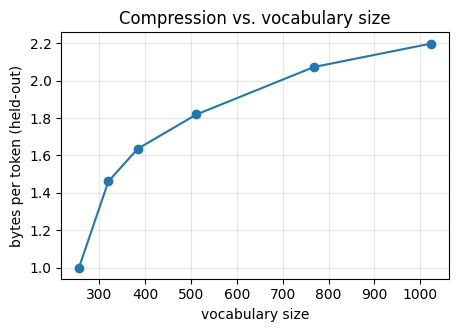

vs= 256  1.00 bytes/token
vs= 320  1.46 bytes/token
vs= 384  1.64 bytes/token
vs= 512  1.82 bytes/token
vs= 768  2.07 bytes/token
vs=1024  2.20 bytes/token


In [9]:
vocab_sizes = [256, 320, 384, 512, 768, 1024]
test_bytes = len(bpe_test_text.encode("utf-8"))

ratios = []

for size in vocab_sizes:
    # Ficar apenas com os primeiros merges necessários
    n_merges = size - 256
    size_merges = dict(list(merges.items())[:n_merges])

    # Codificar o texto de teste
    ids = encode(bpe_test_text, size_merges)

    # bytes por token
    ratio = test_bytes / len(ids)
    ratios.append(ratio)

plt.figure(figsize=(5, 3.2))
plt.plot(vocab_sizes, ratios, "o-")
plt.xlabel("vocabulary size")
plt.ylabel("bytes per token (held-out)")
plt.title("Compression vs. vocabulary size")
plt.grid(alpha=.3)
plt.show()

for vs, r in zip(vocab_sizes, ratios):
    print(f"vs={vs:4d}  {r:.2f} bytes/token")

In [10]:
# CHECK 1.4
assert abs(ratios[0] - 1.0) < 1e-9 and all(b > a for a, b in zip(ratios, ratios[1:]))
print("1.4 OK")

1.4 OK


**Your answer:**  
A curva sobe de 1,00 bytes/token em 256 para 2,20 em 1024, o que significa que um vocabulário maior permite representar o texto com sequências de tokens mais curtas.
A vantagem é, portanto, uma redução do comprimento da sequência. Por outro lado, um vocabulário maior aumenta o tamanho das matrizes de embeddings e de saída, aumentando também os custos de memória e de computação.
Na prática, é necessário encontrar um equilíbrio entre sequências mais curtas e um vocabulário maior, tendo em conta os custos adicionais de memória e processamento.


---
## Part 2 — Production tokenizers and the multilingual token tax

We now use OpenAI's `tiktoken` to load three real tokenizers: `gpt2` (50k vocab, 2019), `cl100k_base` (100k, GPT-3.5/4) and `o200k_base` (200k, GPT-4o). The first call downloads the vocabulary files, so you need internet access.

In [11]:
import tiktoken

encodings = {}
for name in ["gpt2", "cl100k_base", "o200k_base"]:
    try:
        encodings[name] = tiktoken.get_encoding(name)
        print(f"{name:12s} vocab = {encodings[name].n_vocab:,}")
    except Exception as e:
        print(f"{name:12s} could not be loaded ({type(e).__name__}); continuing without it")

gpt2         vocab = 50,257
cl100k_base  vocab = 100,277
o200k_base   vocab = 200,019


### Exercise 2.1 — Your BPE vs. production BPE
Compute bytes/token on `bpe_test_text` for each loaded encoding and compare with your 1024-token BPE.

In [12]:
compression = {"our BPE (1024)": ratios[-1]}

bytes = len(bpe_test_text.encode("utf-8"))

# Calcular bytes/token para cada tokenizer
for name, enc in encodings.items():
    n_tokens = len(enc.encode(bpe_test_text))
    compression[name] = bytes / n_tokens

for k, v in compression.items():
    print(f"{k:15s} {v:.2f} bytes/token")

our BPE (1024)  2.20 bytes/token
gpt2            3.07 bytes/token
cl100k_base     3.49 bytes/token
o200k_base      3.57 bytes/token


**Your answer:**  
Neste conjunto de teste de Shakespeare, o BPE de 1024 tokens obtém 2,20 bytes/token, enquanto o GPT-2 obtém 3,07, o cl100k_base obtém 3,49 e o o200k_base obtém 3,57.
Isto mostra que a adequação ao domínio é importante, mas que o tamanho do vocabulário também tem um papel relevante: os tokenizadores de produção têm vocabulários muito maiores e, ainda assim, conseguem comprimir melhor o texto de Shakespeare, apesar de terem sido treinados com dados muito mais abrangentes.


### Exercise 2.2 — The token tax
`data/parallel_sentences.tsv` holds the same 20 sentences in English, Portuguese, Spanish, German, Russian and Chinese. For each encoding compute the **token premium** of each language:

$$\text{premium}(\ell) = \frac{\#\text{tokens}(\ell)}{\#\text{tokens}(\text{en})}$$

summing over all 20 sentences, and plot a grouped bar chart.

20 sentences in ['en', 'pt', 'es', 'de', 'ru', 'zh']


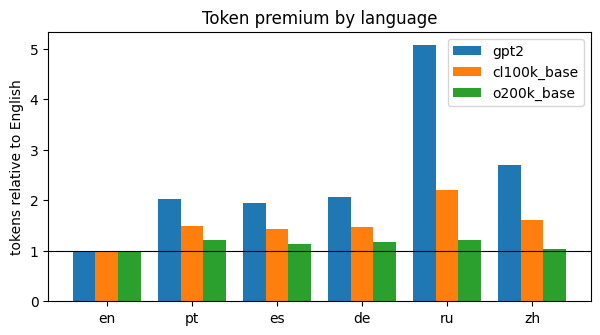

gpt2         en:1.00 pt:2.03 es:1.94 de:2.07 ru:5.09 zh:2.70
cl100k_base  en:1.00 pt:1.49 es:1.43 de:1.47 ru:2.20 zh:1.62
o200k_base   en:1.00 pt:1.21 es:1.14 de:1.17 ru:1.22 zh:1.03


In [13]:
import csv

with open("data/parallel_sentences.tsv", encoding="utf-8") as f:
    rows = list(csv.DictReader(f, delimiter="\t"))

langs = list(rows[0].keys())
print(len(rows), "sentences in", langs)

premium = {}

# Para cada encoding
for name, enc in encodings.items():

    # Total de tokens em cada língua
    totals = {}

    for lang in langs:
        totals[lang] = sum(len(enc.encode(row[lang])) for row in rows)

    # Inglês é a referência
    english_total = totals["en"]

    # tokens da língua / tokens em inglês
    premium[name] = {
        lang: totals[lang] / english_total
        for lang in langs
    }


x = np.arange(len(langs))
w = 0.8 / max(1, len(premium))

plt.figure(figsize=(7, 3.5))

for j, (name, p) in enumerate(premium.items()):
    plt.bar(
        x + j * w,
        [p[l] for l in langs],
        w,
        label=name
    )

plt.axhline(1, color="k", lw=0.8)
plt.xticks(
    x + w * (len(premium) - 1) / 2,
    langs
)
plt.ylabel("tokens relative to English")
plt.legend()
plt.title("Token premium by language")
plt.show()

for name, p in premium.items():
    print(name.ljust(12), " ".join(f"{l}:{p[l]:.2f}" for l in langs))

In [14]:
# CHECK 2.2
for name, p in premium.items():
    assert abs(p["en"] - 1) < 1e-9 and p["ru"] > 1.2, name
print("2.2 OK")

2.2 OK


**Your answer:**  
No GPT-2, o russo apresenta o maior premium, de 5,09×, seguido pelo chinês (2,70×), alemão (2,07×) e português (2,03×).
Com o o200k_base, o premium do russo diminui para 1,22×, uma redução de cerca de 76%, enquanto o português diminui para 1,21×.
Um premium elevado significa maior custo da API, menos palavras a caber numa janela de contexto com tamanho fixo e, potencialmente, mais computação e latência.
Aumentar simplesmente o número de tokens não é uma solução simples, porque um vocabulário maior aumenta o número de parâmetros do modelo e os custos associados aos embeddings e ao softmax. Além disso, os novos tokens precisam de ter dados de treino suficientes para serem realmente úteis.


### Exercise 2.3 — Tokenization artefacts
Many well-known LLM failure modes are tokenization problems in disguise. Use the helper below to inspect the three strings, then answer.

In [15]:
def show(s, name="cl100k_base"):
    enc = encodings.get(name) or next(iter(encodings.values()))
    pieces = [enc.decode([t]) for t in enc.encode(s)]
    print(f"{len(pieces):3d} tokens | " + " | ".join(repr(p) for p in pieces))

for s in ["How many r's are in strawberry?", "12345678 + 87654321 =", " SolidGoldMagikarp"]:
    for name in encodings:
        print(f"{name:12s}", end=" "); show(s, name)
    print()

gpt2           8 tokens | 'How' | ' many' | ' r' | "'s" | ' are' | ' in' | ' strawberry' | '?'
cl100k_base    8 tokens | 'How' | ' many' | ' r' | "'s" | ' are' | ' in' | ' strawberry' | '?'
o200k_base     8 tokens | 'How' | ' many' | ' r' | "'s" | ' are' | ' in' | ' strawberry' | '?'

gpt2           9 tokens | '123' | '45' | '678' | ' +' | ' 87' | '65' | '43' | '21' | ' ='
cl100k_base    9 tokens | '123' | '456' | '78' | ' +' | ' ' | '876' | '543' | '21' | ' ='
o200k_base     9 tokens | '123' | '456' | '78' | ' +' | ' ' | '876' | '543' | '21' | ' ='

gpt2           1 tokens | ' SolidGoldMagikarp'
cl100k_base    5 tokens | ' Solid' | 'Gold' | 'Mag' | 'ik' | 'arp'
o200k_base     5 tokens | ' Solid' | 'Gold' | 'Mag' | 'ik' | 'arp'



**Your answer:**  
A palavra strawberry é dividida em vários tokens, pelo que o modelo não tem necessariamente acesso direto a um único token que represente a palavra completa ou cada uma das suas letras individualmente.
O número 12345678 também é dividido em vários blocos, que podem variar entre diferentes tokenizadores. Assim, para realizar cálculos, o modelo precisa de raciocinar através de vários tokens, em vez de trabalhar com um único objeto numérico.
Isto torna tarefas como contar letras com exatidão e realizar operações com números grandes mais difíceis quando o tokenizador cria fragmentos pouco convenientes.


---
## Part 3 — N-gram language models and perplexity

A language model assigns a probability to every sequence by the chain rule, $p(x_1,\dots,x_T)=\prod_t p(x_t \mid x_{<t})$. An **n-gram** model makes the Markov assumption that only the last $n-1$ symbols matter:

$$p(x_t \mid x_{<t}) \approx p(x_t \mid x_{t-n+1:t-1}) = \frac{c(x_{t-n+1:t}) + k}{c(x_{t-n+1:t-1}) + kV}$$

with **add-k smoothing** ($V$ = vocabulary size). We work at **character level** (V ≈ 65) so the model trains in seconds.

**Perplexity** on a held-out text of $T$ symbols is the exponentiated average negative log-likelihood (i.e. the exponentiated cross-entropy):

$$\mathrm{PPL} = \exp\Big(-\frac{1}{T}\sum_t \log p(x_t\mid x_{<t})\Big)$$

A uniform model has PPL = V. Lower is better.

In [16]:
split = int(0.9 * len(corpus))
train_text, val_text = corpus[:split], corpus[split:]
chars = sorted(set(corpus))
V = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
print(f"V = {V}, train = {len(train_text):,} chars, val = {len(val_text):,} chars")

V = 65, train = 1,003,854 chars, val = 111,540 chars


### Exercise 3.1 — The model
Complete `NGramLM`. `fit` counts all n-grams and their (n−1)-character contexts; `prob` applies add-k smoothing; `perplexity` scores a text starting at position `start` (so that models of different order are scored on exactly the same characters).

In [17]:
class NGramLM:
    def __init__(self, n, k=1.0):
        self.n, self.k = n, k

    def fit(self, text):
        n = self.n
        self.ngram_counts = Counter()
        self.context_counts = Counter()

        for i in range(len(text) - n + 1):
            ngram = text[i:i + n]
            context = text[i:i + n - 1]
            self.ngram_counts[ngram] += 1
            self.context_counts[context] += 1

        return self

    def prob(self, context, ch):
        ctx = context[-(self.n - 1):] if self.n > 1 else ""
        ngram = ctx + ch

        numerator = self.ngram_counts[ngram] + self.k
        denominator = self.context_counts[ctx] + self.k * len(chars)
        return numerator / denominator

    def dist(self, context):
        p = np.array([self.prob(context, c) for c in chars])
        return p / p.sum()

    def perplexity(self, text, start=None):
        start = self.n - 1 if start is None else start
        nll = []

        for t in range(start, len(text)):
            p = self.prob(text[:t], text[t])
            if p == 0:
                return float("inf")
            nll.append(-math.log(p))

        return math.exp(np.mean(nll))


In [18]:
# CHECK 3.1
toy = NGramLM(2, k=0.0).fit("abab")
assert abs(toy.prob("a", "b") - 1.0) < 1e-12
uni = NGramLM(1, k=1.0).fit(train_text)
assert abs(uni.dist("").sum() - 1) < 1e-9
assert 10 < uni.perplexity(val_text[:5000]) < V
print("3.1 OK — unigram PPL:", round(uni.perplexity(val_text[:5000]), 2))

3.1 OK — unigram PPL: 27.32


### Exercise 3.2 — Order and smoothing sweep
For $n \in \{1,\dots,7\}$ and $k \in \{0.01, 0.1, 1\}$, fit on `train_text` and compute PPL on the first 20 000 characters of `val_text` and of `train_text`, always with `start=6`. Plot validation PPL vs. $n$ (one line per $k$) and, for $k=0.1$, train vs. validation PPL. *(Takes ~1 minute.)*

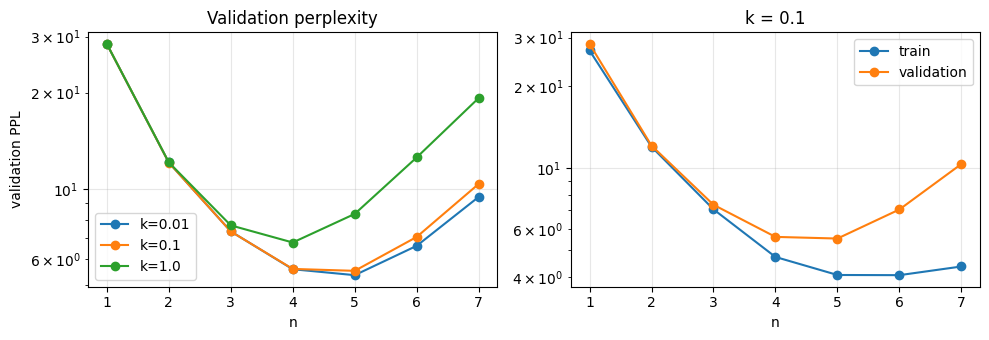

n=1 k=0.01  train=  26.92  val=  28.45
n=1 k=0.1   train=  26.92  val=  28.45
n=1 k=1.0   train=  26.92  val=  28.45
n=2 k=0.01  train=  11.97  val=  12.08
n=2 k=0.1   train=  11.97  val=  12.08
n=2 k=1.0   train=  11.99  val=  12.10
n=3 k=0.01  train=   7.02  val=   7.35
n=3 k=0.1   train=   7.07  val=   7.34
n=3 k=1.0   train=   7.38  val=   7.67
n=4 k=0.01  train=   4.52  val=   5.59
n=4 k=0.1   train=   4.73  val=   5.60
n=4 k=1.0   train=   5.87  val=   6.78
n=5 k=0.01  train=   3.49  val=   5.36
n=5 k=0.1   train=   4.07  val=   5.53
n=5 k=1.0   train=   6.81  val=   8.34
n=6 k=0.01  train=   2.88  val=   6.62
n=6 k=0.1   train=   4.06  val=   7.06
n=6 k=1.0   train=   9.42  val=  12.53
n=7 k=0.01  train=   2.46  val=   9.43
n=7 k=0.1   train=   4.37  val=  10.35
n=7 k=1.0   train=  13.18  val=  19.24


In [19]:
orders, ks = range(1, 8), [0.01, 0.1, 1.0]
val_eval, train_eval = val_text[:20_000], train_text[:20_000]
results = {}

for n in orders:
    model = NGramLM(n, k=ks[0]).fit(train_text)
    for k in ks:
        model.k = k
        train_ppl = model.perplexity(train_eval, start=6)
        val_ppl = model.perplexity(val_eval, start=6)
        results[(n, k)] = (train_ppl, val_ppl)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

for k in ks:
    ax[0].plot(list(orders), [results[(n, k)][1] for n in orders], "o-", label=f"k={k}")
ax[0].set(xlabel="n", ylabel="validation PPL", title="Validation perplexity", yscale="log")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(list(orders), [results[(n, 0.1)][0] for n in orders], "o-", label="train")
ax[1].plot(list(orders), [results[(n, 0.1)][1] for n in orders], "o-", label="validation")
ax[1].set(xlabel="n", title="k = 0.1", yscale="log")
ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

for (n, k), (tr, va) in sorted(results.items()):
    print(f"n={n} k={k:<5} train={tr:7.2f}  val={va:7.2f}")


In [20]:
# CHECK 3.2
best = min(results, key=lambda nk: results[nk][1])
print("best (n, k):", best, "val PPL:", round(results[best][1], 2))
assert 3 <= best[0] <= 6 and results[best][1] < 6
print("3.2 OK")

best (n, k): (5, 0.01) val PPL: 5.36
3.2 OK


**Your answer:**  
A PPL de validação diminui à medida que n aumenta, porque um contexto maior permite captar melhor a estrutura local do texto. No entanto, a partir de determinado ponto, a PPL volta a aumentar, porque os n-grams de ordem elevada são mais raros e tendem a causar overfitting nos dados de treino.
Por exemplo, o melhor resultado é obtido com n=5 e k=0,01, com uma PPL de validação de 5,36, enquanto n=7 apresenta um resultado bastante pior.
Valores maiores de k tornam-se mais prejudiciais para valores elevados de n, porque o smoothing atribui mais probabilidade aos muitos n-grams que não aparecem nos dados de treino. Com k=0, os n-grams não observados na validação recebem probabilidade zero e a PPL torna-se infinita.
A melhor PPL corresponde a aproximadamente 2,42 bits por carácter (log2(5,36)).
A PPL ao nível dos caracteres não pode ser comparada diretamente com a PPL ao nível dos tokens BPE, porque as unidades de previsão são diferentes. É necessário utilizar uma normalização comum, como bits por carácter ou bits por byte.


---
## Part 4 — Decoding strategies

A language model gives a distribution $p(\cdot \mid \text{context})$; a **decoding strategy** turns it into text. Implement the four classic ones on a probability vector `p` (NumPy, sums to 1). Each returns an **index**.

* **Greedy**: argmax.
* **Temperature** $T$: sample from $\mathrm{softmax}(\log p / T)$. $T\to 0$ approaches greedy; $T=1$ is the model; $T>1$ flattens.
* **Top-k**: keep the $k$ most likely, renormalise, sample.
* **Top-p (nucleus)**: keep the *smallest* set of most-likely symbols whose cumulative probability is $\ge p$, renormalise, sample.

In [21]:
def greedy(p, rng):
    return int(np.argmax(p))


def sample_temperature(p, rng, T=1.0):
    log_p = np.log(p)
    logits = log_p / T
    logits -= np.max(logits)
    q = np.exp(logits)
    q /= q.sum()
    return int(rng.choice(len(p), p=q))


def sample_top_k(p, rng, k=5):
    keep = np.argsort(p)[-k:]
    q = np.zeros_like(p)
    q[keep] = p[keep]
    q /= q.sum()
    return int(rng.choice(len(p), p=q))


def nucleus(p, top_p):
    order = np.argsort(p)[::-1]
    cumulative = np.cumsum(p[order])
    cutoff = np.searchsorted(cumulative, top_p)
    return order[:cutoff + 1]


def sample_top_p(p, rng, top_p=0.9):
    keep = nucleus(p, top_p)
    q = np.zeros_like(p)
    q[keep] = p[keep]
    q /= q.sum()
    return int(rng.choice(len(p), p=q))


In [22]:
# CHECK 4.1
_p = np.array([0.5, 0.3, 0.15, 0.05]); _r = np.random.default_rng(1)
assert greedy(_p, _r) == 0
assert set(nucleus(_p, 0.5)) == {0} and set(nucleus(_p, 0.8)) == {0, 1} and set(nucleus(_p, 0.81)) == {0, 1, 2}
assert all(sample_top_k(_p, _r, k=2) in (0, 1) for _ in range(200))
assert all(sample_temperature(_p, _r, T=0.01) == 0 for _ in range(50))
print("4.1 OK")

4.1 OK


### Exercise 4.2 — Generate and compare
Use the 5-gram model with $k=0.01$ as the language model. Complete `generate` and produce 400 characters from the prompt `"ROMEO:\n"` with each strategy.

In [23]:
lm = NGramLM(5, k=0.01).fit(train_text)


def generate(lm, prompt, n_chars, strategy, rng, **kw):
    text = prompt
    for _ in range(n_chars):
        p = lm.dist(text)
        idx = strategy(p, rng, **kw)
        text += chars[idx]
    return text


strategies = {
    "greedy": (greedy, {}),
    "temperature 0.7": (sample_temperature, {"T": 0.7}),
    "temperature 1.3": (sample_temperature, {"T": 1.3}),
    "top-k 5": (sample_top_k, {"k": 5}),
    "top-p 0.9": (sample_top_p, {"top_p": 0.9}),
}

samples = {}
for name, (fn, kw) in strategies.items():
    samples[name] = generate(
        lm, "ROMEO:\n", 400, fn,
        np.random.default_rng(42), **kw
    )
    print(f"===== {name} =====\n{samples[name]}\n")


===== greedy =====
ROMEO:
I will the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the shall the

===== temperature 0.7 =====
ROMEO:
This word:
Why, this housand thright of my hour name, so might to piece of his some a sighs bait fellows, let's he words, and he served with my lord,
With the servantagenerate out to his break the the will be not to beggarly unmade your reast sorrow to feel and her face been dissemble and thoughter, and me hath he is to his son thee senators promise of such the powers can by ster.

VOLUMNIA:
If sh

===== temperature 1.3 =====
ROMEO:
Sir, you jnvcoPBX&ockKytl?R!:fjxILR?.RBePpgHpnMFf3?
meglQX3-eRXkcWXG!PANqC$FGeXleNn: 'tis and for Ru

### Exercise 4.3 — Quantifying the quality–diversity trade-off
Implement two metrics and sweep temperature $T \in \{0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5\}$, generating 3 samples of 600 characters per value:

* **distinct-2**: number of *distinct* word bigrams divided by the total number of word bigrams (words = `text.split()`); higher = more diverse.
* **model NLL**: the average $-\log p$ **under the model at $T=1$** of the generated characters (excluding the prompt); lower = the text is more "typical" for the model.

Plot NLL (y) against distinct-2 (x), annotating each point with its $T$.

In [24]:
def distinct_2(text):
    words = text.split()
    bigrams = list(zip(words, words[1:]))
    return 0.0 if not bigrams else len(set(bigrams)) / len(bigrams)


def model_nll(lm, text, prompt_len):
    nll = []
    for t in range(prompt_len, len(text)):
        p = lm.prob(text[:t], text[t])
        if p == 0:
            return float("inf")
        nll.append(-math.log(p))
    return float(np.mean(nll))


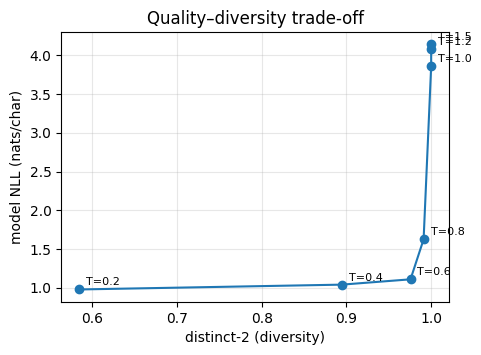

In [25]:
temps = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5]
prompt = "ROMEO:\n"
curve = []

for T in temps:
    d, l = [], []
    for seed in range(3):
        s = generate(
            lm, prompt, 600, sample_temperature,
            np.random.default_rng(seed), T=T
        )
        d.append(distinct_2(s[len(prompt):]))
        l.append(model_nll(lm, s, len(prompt)))
    curve.append((T, np.mean(d), np.mean(l)))

plt.figure(figsize=(5, 3.5))
plt.plot([c[1] for c in curve], [c[2] for c in curve], "o-")
for T, d, l in curve:
    plt.annotate(
        f"T={T}", (d, l),
        textcoords="offset points", xytext=(5, 3), fontsize=8
    )
plt.xlabel("distinct-2 (diversity)")
plt.ylabel("model NLL (nats/char)")
plt.title("Quality–diversity trade-off")
plt.grid(alpha=.3)
plt.show()


In [26]:
# CHECK 4.3
assert curve[0][1] < curve[-1][1] and curve[0][2] < curve[-1][2]
g = samples["greedy"][len("ROMEO:\n"):]
print("greedy distinct-2:", round(distinct_2(g), 2), "| top-p distinct-2:", round(distinct_2(samples["top-p 0.9"][7:]), 2))
print("4.3 OK")

greedy distinct-2: 0.05 | top-p distinct-2: 1.0
4.3 OK


**Your answer:**  
A descodificação greedy pode entrar em ciclos porque o carácter localmente mais provável pode criar um contexto que torna a mesma sequência novamente muito provável. Assim, não existe nenhum mecanismo que incentive a exploração de outras possibilidades.
A curva mostra o compromisso habitual entre qualidade e diversidade: para escrita criativa, utilizaria uma temperatura moderada, aproximadamente 0,7–1,0. Para completar código, preferiria uma temperatura mais baixa, aproximadamente 0,2–0,6.
Uma NLL baixa significa apenas que o texto é provável segundo este modelo. Não garante que o texto esteja correto, coerente, original ou útil.


### Exercise 4.4 — Why nucleus sampling adapts
Print the nucleus size (number of characters kept at `top_p=0.9`) for the contexts below. Then answer.

In [27]:
for ctx in ["ROMEO", "KING RICHAR", "What is th", "and the ", "speak.\n\n"]:
    p = lm.dist(ctx)
    print(f"{ctx!r:16s} nucleus size = {len(nucleus(p, 0.9)):2d} | top char = {chars[int(p.argmax())]!r} ({p.max():.2f})")

'ROMEO'          nucleus size =  1 | top char = ':' (1.00)
'KING RICHAR'    nucleus size =  1 | top char = 'D' (1.00)
'What is th'     nucleus size =  4 | top char = 'e' (0.55)
'and the '       nucleus size = 19 | top char = 's' (0.09)
'speak.\n\n'     nucleus size = 15 | top char = 'K' (0.14)


**Your answer:**  
Os tamanhos do nucleus apresentados variam consoante o contexto, porque algumas situações têm uma distribuição de probabilidades muito concentrada para o próximo carácter, enquanto outras são mais incertas.
Assim, o top-p mantém apenas alguns caracteres quando a maior parte da probabilidade está concentrada em poucas opções e mantém mais caracteres quando a probabilidade está mais distribuída.
Por outro lado, um top-k fixo mantém sempre exatamente o mesmo número de caracteres.
Desta forma, o top-p é mais adaptativo aos diferentes contextos.


---
## Part 5 — Scaling laws, back of the envelope (homework)

Two results from the scaling-laws literature let you reason about training budgets:

1. **Training compute.** For a dense Transformer with $N$ parameters trained on $D$ tokens, $C \approx 6ND$ FLOPs (2 for the forward pass, 4 for the backward pass, per parameter per token).
2. **Chinchilla** (Hoffmann et al., 2022). For a fixed $C$, loss is minimised with roughly **20 tokens per parameter**. The paper also fits a parametric loss

$$L(N,D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}},\qquad E=1.69,\ A=406.4,\ B=410.7,\ \alpha=0.34,\ \beta=0.28.$$

Assume training on H100 GPUs at 989 TFLOP/s peak (dense BF16) with a **model FLOPs utilisation (MFU) of 40%**.

### Exercise 5.1 — Compute-optimal allocation
Implement `chinchilla_rule(C)` (returns $N, D$ with $D = 20N$ and $6ND = C$) and `gpu_days(C, n_gpus)`. Fill in the table for $C \in \{10^{21}, 10^{23}, 10^{25}\}$ with 1 024 GPUs.

In [28]:
H100_PEAK, MFU = 989e12, 0.40

def chinchilla_rule(C):
    N = math.sqrt(C / 120)
    D = 20 * N
    return N, D


def gpu_days(C, n_gpus):
    seconds = C / (H100_PEAK * MFU * n_gpus)
    return seconds / 86400


print(f"{'C (FLOPs)':>10} | {'N (params)':>11} | {'D (tokens)':>11} | {'days @1024 H100':>15}")
for C in [1e21, 1e23, 1e25]:
    N, D = chinchilla_rule(C)
    print(f"{C:10.0e} | {N:11.2e} | {D:11.2e} | {gpu_days(C, 1024):15.2f}")


 C (FLOPs) |  N (params) |  D (tokens) | days @1024 H100
     1e+21 |    2.89e+09 |    5.77e+10 |            0.03
     1e+23 |    2.89e+10 |    5.77e+11 |            2.86
     1e+25 |    2.89e+11 |    5.77e+12 |          285.71


In [29]:
# CHECK 5.1
N, D = chinchilla_rule(1e23)
assert abs(6 * N * D - 1e23) / 1e23 < 1e-9 and abs(D / N - 20) < 1e-9
print("5.1 OK")

5.1 OK


### Exercise 5.2 — Using the parametric loss
For each $C$ above, find numerically the $N$ that minimises $L(N, C/6N)$ (search over a log-spaced grid of $N$ from $10^7$ to $10^{13}$). Report $N^*$, $D^*$, the tokens-per-parameter ratio $D^*/N^*$ and $L^*$. Plot $L$ vs. $N$ for the three budgets (the "IsoFLOP" curves).

C=1e+21 | N*=1.820e+09 | D*=9.156e+10 | D/N=50.30 | L*=2.3289
C=1e+23 | N*=1.457e+10 | D*=1.144e+12 | D/N=78.47 | L*=2.0050
C=1e+25 | N*=1.167e+11 | D*=1.428e+13 | D/N=122.40 | L*=1.8453


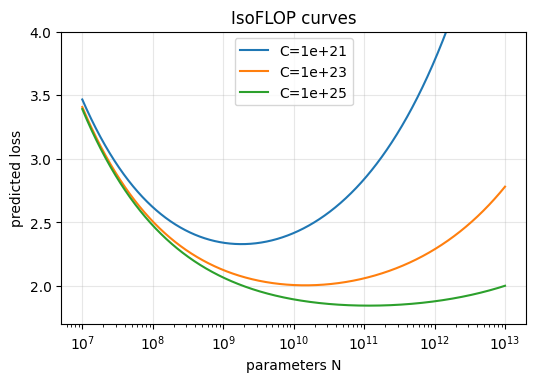

In [30]:
E, A, B, alpha, beta = 1.69, 406.4, 410.7, 0.34, 0.28

def chinchilla_loss(N, D):
    return E + A / N**alpha + B / D**beta


Ns = np.logspace(7, 13, 2000)

plt.figure(figsize=(6, 3.8))

for C in [1e21, 1e23, 1e25]:
    D = C / (6 * Ns)
    losses = chinchilla_loss(Ns, D)
    j = np.argmin(losses)

    N_star = Ns[j]
    D_star = D[j]
    L_star = losses[j]

    print(
        f"C={C:.0e} | N*={N_star:.3e} | D*={D_star:.3e} | "
        f"D/N={D_star/N_star:.2f} | L*={L_star:.4f}"
    )
    plt.plot(Ns, losses, label=f"C={C:.0e}")

plt.xscale("log")
plt.ylim(1.7, 4)
plt.xlabel("parameters N")
plt.ylabel("predicted loss")
plt.title("IsoFLOP curves")
plt.legend()
plt.grid(alpha=.3)
plt.show()


**Your answer:**  
Não. Com o ajuste paramétrico apresentado, os valores ótimos numéricos são aproximadamente 50,3, 78,5 e 122,4 tokens por parâmetro para, respetivamente, \(10^{21}\), \(10^{23}\) e \(10^{25}\) FLOPs, em vez de um valor constante de 20.
Isto mostra que as leis de escala ajustadas podem ser sensíveis aos expoentes utilizados no ajuste e ao intervalo de extrapolação. Besiroglu et al. (2024) identificaram inconsistências importantes nas estimativas paramétricas originais e mostraram que um ajuste recalculado conduz a uma política muito mais próxima da regra de aproximadamente 20 tokens por parâmetro.


### Exercise 5.3 — Why "over-train"?
Meta reports training Llama 3 8B on about **15 trillion tokens**.

(a) Compute its training compute $C$, its tokens-per-parameter ratio, and the Chinchilla-optimal $N$ for that same $C$.
(b) Estimate its training time on 1 024 H100s with your `gpu_days`.
(c) Explain why a lab would deliberately train a model far smaller than compute-optimal. Your answer must mention inference.

In [31]:
N = 8e9
D = 15e12

C = 6 * N * D
tokens_per_parameter = D / N
N_opt, D_opt = chinchilla_rule(C)

print(f"Training compute C = {C:.2e} FLOPs")
print(f"Tokens/parameter = {tokens_per_parameter:.0f}")
print(f"Chinchilla-optimal N = {N_opt:.2e} parameters")
print(f"Chinchilla-optimal D = {D_opt:.2e} tokens")
print(f"Training time on 1024 H100s = {gpu_days(C, 1024):.2f} GPU-days")


Training compute C = 7.20e+23 FLOPs
Tokens/parameter = 1875
Chinchilla-optimal N = 7.75e+10 parameters
Chinchilla-optimal D = 1.55e+12 tokens
Training time on 1024 H100s = 20.57 GPU-days


**Your answer:**  
Para um modelo com 8 mil milhões de parâmetros treinado com 15 biliões de tokens, o custo computacional é de 7,2 × 10²³ FLOPs e a razão de treino é de 1.875 tokens por parâmetro.
Aplicando a regra simples de Chinchilla de 20 tokens por parâmetro, seriam necessários cerca de 77,46 mil milhões de parâmetros para o mesmo orçamento computacional e aproximadamente 1,55 biliões de tokens. Com 1.024 H100, a 40% de MFU, o treino demoraria cerca de 20,57 dias de GPU.
Um laboratório pode, deliberadamente, escolher um modelo muito mais pequeno e treiná-lo com muito mais tokens porque um modelo menor é mais barato e mais fácil de utilizar em produção. O menor consumo de memória e a menor latência e custo por consulta durante a inferência podem compensar o maior custo computacional do treino.


---
## Submission checklist
- [ ] All `# CHECK` cells pass.
- [ ] Every *Your answer* cell is filled, citing your own numbers.
- [ ] Notebook runs top to bottom (`Kernel → Restart & Run All`) in under 5 minutes.
- [ ] File named `PL1_<student1>_<student2>.ipynb`, uploaded to the course page.